# 问题四：A/B 混合介质最低成本与独立统计认证



## 1. 统一模型与计算口径


In [38]:
from pathlib import Path
from itertools import product
from dataclasses import dataclass
import math, os, platform, time, hashlib, types

import numpy as np
import pandas as pd
import scipy
from scipy.stats import beta
from scipy.spatial import cKDTree
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# cache: 直接读取随 Q4 文件夹提供的正式缓存；production: 从头重算两阶段。
RUN_MODE = "cache"
N_JOBS = min(10, os.cpu_count() or 1)
BASE_SEED = 20260808

DISCOVERY_TRIALS = 10000
VALIDATION_TRIALS = 10000
VALIDATION_START = 10000
A_LEVELS = np.arange(550, 612, dtype=np.int16)
DISCOVERY_B_MAX = 518
POINT_TARGET = 0.90
ROBUST_TARGET = 0.91
FROZEN_A = 611
FROZEN_B = 25

WORKSPACE_DIR = Path.cwd()
Q4_DIR = WORKSPACE_DIR / "Q4" if (WORKSPACE_DIR / "Q4").is_dir() else WORKSPACE_DIR
RESULT_DIR = Q4_DIR / "results"
VALIDATION_DIR = Q4_DIR / "validation"
DISCOVERY_CACHE = RESULT_DIR / "q4_discovery_10000_A550_611.npz"
VALIDATION_CACHE = VALIDATION_DIR / "q4_frozen_611A_25B_seed20260808_trials10000_19999.npz"


## 2. 精确截断圆柱、GJK 与并查集内核



In [ ]:
from dataclasses import dataclass
from itertools import combinations, product
import math
import time

import numpy as np
import pandas as pd
from scipy.optimize import minimize

BOX_HALF = 5000.0
BOX_MIN = np.full(3, -BOX_HALF)
BOX_MAX = np.full(3, BOX_HALF)
PERIOD = np.full(3, 2.0 * BOX_HALF)
LENGTH = 5000.0
RADIUS = 30.0
THRESHOLD = 1.8
NUM_TOL = 1e-5
FEAS_TOL = 2e-7
SUPPORT_FEAS_TOL = 1e-9
CONTACT_LIMIT = THRESHOLD + NUM_TOL
SUPPORT_STABILITY_NM = 1e-5
NEAR_THRESHOLD_TOL = 1e-4
GJK_GAP_TOL = 1e-5
GJK_FAR_GUARD = 1e-2

class DynamicUnionFind:
    def __init__(self):
        self.parent = []
        self.rank = []

    def add(self):
        index = len(self.parent)
        self.parent.append(index)
        self.rank.append(0)
        return index

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        a, b = self.find(a), self.find(b)
        if a == b:
            return False
        if self.rank[a] < self.rank[b]:
            a, b = b, a
        self.parent[b] = a
        if self.rank[a] == self.rank[b]:
            self.rank[a] += 1
        return True

    def connected(self, a, b):
        return self.find(a) == self.find(b)


class Cylinder:
    def __init__(self, p, q, radius=RADIUS):
        self.p = np.asarray(p, float)
        self.q = np.asarray(q, float)
        self.radius = float(radius)
        v = self.q - self.p
        self.length = float(np.linalg.norm(v))
        if self.length <= 1e-12:
            raise ValueError("cylinder axis must have positive length")
        self.u = v / self.length
        self.center = 0.5 * (self.p + self.q)
        self.h = 0.5 * self.length
        extent = self.h * np.abs(self.u) + self.radius * np.sqrt(np.maximum(0.0, 1.0-self.u**2))
        self.aabb_min = self.center - extent
        self.aabb_max = self.center + extent

    def translated(self, shift):
        return Cylinder(self.p + shift, self.q + shift, self.radius)

    def support(self, direction):
        d = np.asarray(direction, float)
        axial = float(d @ self.u)
        radial = d - axial * self.u
        radial_norm = float(np.linalg.norm(radial))
        point = self.center + (self.h if axial >= 0 else -self.h) * self.u
        if radial_norm > 1e-14:
            point = point + self.radius * radial / radial_norm
        return point


def orthobasis(u):
    u = np.asarray(u, float)
    helper = np.eye(3)[int(np.argmin(np.abs(u)))]
    v = np.cross(u, helper)
    v /= np.linalg.norm(v)
    w = np.cross(u, v)
    return np.column_stack((u, v, w))


def axis_segment_in_box(cylinder, lo, hi):
    t0, t1 = -cylinder.h, cylinder.h
    for j in range(3):
        uj = float(cylinder.u[j])
        if abs(uj) <= 1e-14:
            if not (lo[j]-1e-8 <= cylinder.center[j] <= hi[j]+1e-8):
                return None
            continue
        a = (lo[j] - cylinder.center[j]) / uj
        b = (hi[j] - cylinder.center[j]) / uj
        t0, t1 = max(t0, min(a,b)), min(t1, max(a,b))
        if t0 > t1 + 1e-8:
            return None
    if t1-t0 <= 1e-8:
        return None
    return cylinder.center+t0*cylinder.u, cylinder.center+t1*cylinder.u


def normalized_geometry(cylinder, lo, hi):
    q = orthobasis(cylinder.u)
    matrix = q @ np.diag([cylinder.h, cylinder.radius, cylinder.radius])
    scale = np.maximum(hi-lo, 1.0)
    a = np.vstack((matrix/scale[:,None], -matrix/scale[:,None]))
    b = np.r_[(hi-cylinder.center)/scale, (cylinder.center-lo)/scale]
    return matrix, a, b


def y_violation(cylinder, matrix, y, lo, hi):
    x = cylinder.center + matrix @ y
    axial = max(0.0, abs(float(y[0]))-1.0) * cylinder.h
    radial = max(0.0, float(np.linalg.norm(y[1:]))-1.0) * cylinder.radius
    box = max(0.0, float(np.max(lo-x)), float(np.max(x-hi)))
    return max(axial, radial, box)


def dykstra_start(y,a,b,cycles=20):
    """Project a y-point onto bounds, radial disk and box half-spaces."""
    projectors=[
        lambda z:np.clip(z,-1.0,1.0),
        lambda z:np.r_[z[0],z[1:]/max(1.0,float(np.linalg.norm(z[1:])))],
    ]
    for row,rhs in zip(a,b):
        denominator=float(row@row)
        projectors.append(
            lambda z,row=row,rhs=rhs,denominator=denominator:
                z-max(0.0,float(row@z-rhs))/denominator*row
        )
    point=np.asarray(y,float).copy()
    corrections=[np.zeros(3) for _ in projectors]
    for _ in range(cycles):
        for index,project in enumerate(projectors):
            shifted=point+corrections[index]
            updated=project(shifted)
            corrections[index]=shifted-updated
            point=updated
    return point


def recover_feasible_y(cylinder,matrix,a,b,y,tolerance=SUPPORT_FEAS_TOL):
    """Return a strictly feasible primal point, or None if projection stalls."""
    point=np.asarray(y,float).copy()
    if y_violation(cylinder,matrix,point,BOX_MIN,BOX_MAX)<=tolerance:
        return point
    for cycles in (20,100,500,1500):
        point=dykstra_start(point,a,b,cycles=cycles)
        if y_violation(cylinder,matrix,point,BOX_MIN,BOX_MAX)<=tolerance:
            return point
    return None


def cylinder_box_feasible(cylinder, lo, hi):
    if np.any(cylinder.aabb_max < lo-1e-9) or np.any(cylinder.aabb_min > hi+1e-9):
        return None
    segment = axis_segment_in_box(cylinder, lo, hi)
    if segment is not None:
        return 0.5*(segment[0]+segment[1])

    matrix, a, b = normalized_geometry(cylinder, lo, hi)
    closest = np.clip(cylinder.center, lo, hi)
    y0 = np.linalg.solve(matrix, closest-cylinder.center)
    y0[0] = np.clip(y0[0], -1.0, 1.0)
    radial = np.linalg.norm(y0[1:])
    if radial > 1.0:
        y0[1:] /= radial
    constraints = [
        {"type":"ineq", "fun":lambda y: b-a@y, "jac":lambda y: -a},
        {"type":"ineq", "fun":lambda y: 1-y[1]**2-y[2]**2,
         "jac":lambda y: np.array([0.0,-2*y[1],-2*y[2]])},
    ]
    starts = [y0, np.zeros(3)]
    for start in starts:
        result = minimize(
            lambda y: 0.5*float(np.dot(y-start,y-start)), start,
            jac=lambda y: y-start, method="SLSQP", bounds=[(-1,1)]*3,
            constraints=constraints, options={"ftol":1e-10,"maxiter":300},
        )
        y = result.x
        if y_violation(cylinder, matrix, y, lo, hi) <= FEAS_TOL:
            return cylinder.center + matrix@y
    return None


class Fragment:
    def __init__(self, parent_id, integer_shift, cylinder, feasible_point):
        self.parent_id = int(parent_id)
        self.integer_shift = tuple(int(x) for x in integer_shift)
        self.cylinder = cylinder
        self.center = 0.5*(np.maximum(cylinder.aabb_min,BOX_MIN)+np.minimum(cylinder.aabb_max,BOX_MAX))
        self.aabb_min = np.maximum(cylinder.aabb_min, BOX_MIN)
        self.aabb_max = np.minimum(cylinder.aabb_max, BOX_MAX)
        self.matrix, self.a, self.b = normalized_geometry(cylinder, BOX_MIN, BOX_MAX)
        initial_feasible_y=np.linalg.solve(self.matrix,feasible_point-cylinder.center)
        recovered_feasible_y=recover_feasible_y(
            cylinder,self.matrix,self.a,self.b,initial_feasible_y
        )
        self.feasible_y=(
            recovered_feasible_y if recovered_feasible_y is not None
            else initial_feasible_y
        )
        if y_violation(cylinder,self.matrix,self.feasible_y,BOX_MIN,BOX_MAX)>FEAS_TOL:
            raise RuntimeError("fragment has no numerically feasible seed point")
        self.cache = {}
        self.optimized_calls = 0
        self.solver_fallbacks = 0
        self.stability_accepts = 0
        self.dykstra_retries = 0
        self.projection_recoveries = 0

    def clear_support_cache(self):
        self.cache.clear()

    def support(self, direction):
        d = np.asarray(direction,float)
        norm = float(np.linalg.norm(d))
        if norm <= 1e-14:
            return self.cylinder.center+self.matrix@self.feasible_y
        d /= norm
        key = tuple(float(value) for value in d)
        if key in self.cache:
            return self.cache[key].copy()
        analytic = self.cylinder.support(d)
        if np.all(analytic >= BOX_MIN-SUPPORT_FEAS_TOL) and np.all(analytic <= BOX_MAX+SUPPORT_FEAS_TOL):
            self.cache[key] = analytic.copy()
            return analytic
        p = self.matrix.T@d
        objective_scale=max(float(np.linalg.norm(p)),1.0)
        p /= objective_scale
        start = np.zeros(3)
        start[0] = 1.0 if p[0]>=0 else -1.0
        rn = np.linalg.norm(p[1:])
        if rn>0: start[1:] = p[1:]/rn
        constraints = [
            {"type":"ineq","fun":lambda y:self.b-self.a@y,"jac":lambda y:-self.a},
            {"type":"ineq","fun":lambda y:1-y[1]**2-y[2]**2,
             "jac":lambda y:np.array([0.0,-2*y[1],-2*y[2]])},
        ]
        candidates=[]

        def solve_from(initial,ftol,maxiter,source):
            result=minimize(lambda y:-float(p@y),initial,jac=lambda y:-p,
                            method="SLSQP",bounds=[(-1,1)]*3,constraints=constraints,
                            options={"ftol":ftol,"maxiter":maxiter})
            recovered=recover_feasible_y(
                self.cylinder,self.matrix,self.a,self.b,result.x
            )
            if recovered is not None:
                if np.linalg.norm(recovered-result.x)>1e-12:
                    self.projection_recoveries += 1
                candidates.append((float(p@recovered),recovered,result.success,source))
            return bool(result.success and recovered is not None)

        first_success=solve_from(start,1e-10,300,"extreme")
        if not first_success:
            self.solver_fallbacks += 1
            solve_from(self.feasible_y,1e-12,1000,"feasible")
            box_start=np.linalg.solve(
                self.matrix,
                np.clip(analytic,BOX_MIN,BOX_MAX)-self.cylinder.center,
            )
            solve_from(np.clip(box_start,-1.0,1.0),1e-12,1000,"box")
            projected_start=dykstra_start(start,self.a,self.b,cycles=50)
            solve_from(projected_start,1e-12,1000,"dykstra")
            self.dykstra_retries += 1

            if len(candidates)<2:
                extra_starts=(
                    np.zeros(3),
                    -start,
                    0.5*(self.feasible_y+start),
                    0.5*(self.feasible_y+np.clip(box_start,-1.0,1.0)),
                )
                for extra_index,extra_start in enumerate(extra_starts):
                    solve_from(extra_start,1e-12,1500,f"extra_{extra_index}")
                self.dykstra_retries += len(extra_starts)

        if not candidates:
            raise RuntimeError("fragment support produced no strictly feasible primal candidate")
        best=max(candidates,key=lambda z:z[0])
        _,y,success,_=best
        if not first_success:
            other_values=sorted(
                (candidate[0] for candidate in candidates if candidate is not best),
                reverse=True,
            )
            support_spread_nm=(best[0]-other_values[0])*objective_scale if other_values else math.inf
            if support_spread_nm<=SUPPORT_STABILITY_NM:
                self.stability_accepts += 1
                success=True
        self.optimized_calls += 1
        if not success:
            raise RuntimeError(
                "fragment support remained unresolved after retry; "
                f"strict objectives/status={[(value, ok, source) for value, _, ok, source in candidates]}"
            )
        point=self.cylinder.center+self.matrix@y
        if y_violation(self.cylinder,self.matrix,y,BOX_MIN,BOX_MAX)>SUPPORT_FEAS_TOL:
            raise RuntimeError("support point lost strict primal feasibility")
        self.cache[key]=point.copy()
        return point


def fragment_shift_ranges(cylinder):
    lower=np.ceil((cylinder.aabb_min-BOX_MAX)/PERIOD-1e-12).astype(int)
    upper=np.floor((cylinder.aabb_max-BOX_MIN)/PERIOD+1e-12).astype(int)
    return [range(int(lower[j]),int(upper[j])+1) for j in range(3)]


def generate_parent_fragments(parent_id, cylinder):
    fragments=[]
    for k in product(*fragment_shift_ranges(cylinder)):
        k=np.asarray(k,int)
        shifted=cylinder.translated(-k*PERIOD)
        feasible=cylinder_box_feasible(shifted,BOX_MIN,BOX_MAX)
        if feasible is not None:
            fragments.append(Fragment(parent_id,k,shifted,feasible))
    return fragments

@dataclass
class SupportPoint:
    w: np.ndarray
    a: np.ndarray
    b: np.ndarray


@dataclass
class GJKResult:
    lower: float
    upper: float
    a: np.ndarray
    b: np.ndarray
    status: str


def closest_simplex(simplex):
    points=np.asarray([s.w for s in simplex])
    best=None
    for size in range(1,min(4,len(simplex))+1):
        for ids in combinations(range(len(simplex)),size):
            ids=np.asarray(ids,int); face=points[ids]
            gram=face@face.T
            kkt=np.block([[gram,np.ones((size,1))],[np.ones((1,size)),np.zeros((1,1))]])
            lam=np.linalg.lstsq(kkt,np.r_[np.zeros(size),1.0],rcond=None)[0][:size]
            if np.min(lam)<-1e-9: continue
            lam=np.maximum(lam,0); lam/=lam.sum()
            close=lam@face; value=float(close@close)
            if best is None or value<best[0]: best=(value,ids,lam,close)
    _,ids,lam,close=best
    pa=sum(lam[t]*simplex[idx].a for t,idx in enumerate(ids))
    pb=sum(lam[t]*simplex[idx].b for t,idx in enumerate(ids))
    return close,ids,pa,pb


def gjk(shape_a,shape_b,threshold=THRESHOLD,allow_lower=True,maxiter=100):
    def supp(d):
        a=shape_a.support(d); b=shape_b.support(-np.asarray(d,float))
        return SupportPoint(a-b,a,b)
    direction=shape_b.center-shape_a.center
    if np.linalg.norm(direction)<1e-14: direction=np.array([1.,0,0])
    simplex=[supp(direction)]; lower=0.0; pa=simplex[0].a; pb=simplex[0].b
    for _ in range(maxiter):
        close,active,pa,pb=closest_simplex(simplex)
        simplex=[simplex[i] for i in active]
        upper=float(np.linalg.norm(close))
        if upper<=1e-10: return GJKResult(0,0,pa,pb,"intersect")
        if threshold is not None and upper<=threshold+NUM_TOL: return GJKResult(lower,upper,pa,pb,"connected")
        new=supp(-close)
        lower=max(lower,max(0.0,float(close@new.w/upper)))
        if threshold is not None and allow_lower and lower>threshold+NUM_TOL:
            return GJKResult(lower,upper,pa,pb,"separated")
        duplicate=any(np.linalg.norm(new.w-old.w)<=1e-9 for old in simplex)
        if duplicate or upper-lower<=1e-9*max(1.,upper):
            return GJKResult(lower,upper,pa,pb,"converged")
        simplex.append(new)
    return GJKResult(lower,float(np.linalg.norm(pa-pb)),pa,pb,"maxiter")


def segment_distances_one_to_many(p,q,p2,q2):
    d1=q-p
    d2=q2-p2
    r=p[None,:]-p2
    a=float(d1@d1)
    e=np.einsum('ij,ij->i',d2,d2)
    b=d2@d1
    c=r@d1
    f=np.einsum('ij,ij->i',d2,r)
    denom=a*e-b*b
    s=np.zeros_like(denom)
    np.divide(b*f-c*e,denom,out=s,where=denom>1e-12)
    s=np.clip(s,0,1)
    t=(b*s+f)/e
    low=t<0; high=t>1
    t=np.clip(t,0,1)
    s=np.where(low,np.clip(-c/a,0,1),s)
    s=np.where(high,np.clip((b-c)/a,0,1),s)
    cp1=p[None,:]+s[:,None]*d1
    cp2=p2+t[:,None]*d2
    dist=np.linalg.norm(cp1-cp2,axis=1)
    return dist,s,t,cp1,cp2


def in_box(point):
    return bool(np.all(point>=BOX_MIN-2e-7) and np.all(point<=BOX_MAX+2e-7))


def fragments_connect(a,b,axis_distance,s,t,cp_a,cp_b,stats):
    # 最常见的侧面-侧面情形可直接构造盒内见证点。
    if 1e-9<s<1-1e-9 and 1e-9<t<1-1e-9:
        v=cp_b-cp_a; d=float(axis_distance)
        if d<=2*RADIUS:
            wa=wb=0.5*(cp_a+cp_b)
        else:
            wa=cp_a+RADIUS*v/d
            wb=cp_b-RADIUS*v/d
        if in_box(wa) and in_box(wb):
            if float(np.linalg.norm(wa-wb))<=CONTACT_LIMIT:
                stats['side_witness']+=1
                return True
    stats['full_gjk']+=1
    full=gjk(a.cylinder,b.cylinder,allow_lower=True)
    if full.lower>CONTACT_LIMIT:
        return False
    if full.upper<=CONTACT_LIMIT and in_box(full.a) and in_box(full.b):
        return True
    stats['clipped_gjk']+=1
    clipped=gjk(a,b,allow_lower=False,maxiter=180)
    if clipped.status=="maxiter":
        raise RuntimeError("clipped GJK did not converge")
    if clipped.upper<=CONTACT_LIMIT:
        return True
    gap=abs(clipped.upper-clipped.lower)
    separated=(
        clipped.lower>CONTACT_LIMIT
        and (gap<=GJK_GAP_TOL or min(clipped.lower,clipped.upper)>CONTACT_LIMIT+GJK_FAR_GUARD)
    )
    if abs(clipped.upper-THRESHOLD)<=NEAR_THRESHOLD_TOL or not separated:
        a.clear_support_cache(); b.clear_support_cache()
        clipped=gjk(a,b,allow_lower=False,maxiter=500)
        if clipped.status=="maxiter":
            raise RuntimeError("near-threshold clipped GJK did not converge")
        stats['near_threshold']+=1
        if clipped.upper<=CONTACT_LIMIT:
            return True
        gap=abs(clipped.upper-clipped.lower)
        separated=(
            clipped.lower>CONTACT_LIMIT
            and (gap<=GJK_GAP_TOL or min(clipped.lower,clipped.upper)>CONTACT_LIMIT+GJK_FAR_GUARD)
        )
        if not separated:
            raise RuntimeError(
                "clipped GJK remained numerically unresolved: "
                f"lower={clipped.lower}, upper={clipped.upper}"
            )
    return False

def sample_cylinders(n,rng):
    centers=rng.uniform(-BOX_HALF,BOX_HALF,size=(n,3))
    directions=rng.normal(size=(n,3))
    directions/=np.linalg.norm(directions,axis=1,keepdims=True)
    p=centers-0.5*LENGTH*directions
    q=centers+0.5*LENGTH*directions
    return [Cylinder(p[i],q[i]) for i in range(n)]


def simulate_nested(seed,n_levels=np.array([354,424,495,707]),base_seed=20260808):
    seed_sequence=np.random.SeedSequence([int(base_seed),int(seed)])
    rng=np.random.Generator(np.random.PCG64(seed_sequence))
    cylinders=sample_cylinders(int(n_levels[-1]),rng)
    dsu=DynamicUnionFind(); left=dsu.add(); right=dsu.add()
    capacity=8*int(n_levels[-1])
    mins=np.empty((capacity,3)); maxs=np.empty((capacity,3))
    ps=np.empty((capacity,3)); qs=np.empty((capacity,3))
    fragments=[]; indicators=np.zeros(len(n_levels),dtype=bool)
    stats={'fragments':0,'aabb_candidates':0,'axis_candidates':0,'side_witness':0,
           'full_gjk':0,'clipped_gjk':0,'support_calls':0,'fallbacks':0,
           'dykstra_retries':0,'projection_recoveries':0,
           'stability_accepts':0,'near_threshold':0}
    level=0
    left_slab_min=BOX_MIN.copy(); left_slab_max=BOX_MAX.copy(); left_slab_max[0]=BOX_MIN[0]+CONTACT_LIMIT
    right_slab_min=BOX_MIN.copy(); right_slab_min[0]=BOX_MAX[0]-CONTACT_LIMIT; right_slab_max=BOX_MAX.copy()

    for parent_id,cylinder in enumerate(cylinders):
        for frag in generate_parent_fragments(parent_id,cylinder):
            node=dsu.add(); m=len(fragments)
            if frag.aabb_min[0]<=left_slab_max[0]+1e-10 and cylinder_box_feasible(frag.cylinder,left_slab_min,left_slab_max) is not None:
                dsu.union(left,node)
            if frag.aabb_max[0]>=right_slab_min[0]-1e-10 and cylinder_box_feasible(frag.cylinder,right_slab_min,right_slab_max) is not None:
                dsu.union(right,node)
            if m:
                gap=np.maximum(0.0,np.maximum(frag.aabb_min-maxs[:m],mins[:m]-frag.aabb_max))
                ids=np.flatnonzero(np.einsum('ij,ij->i',gap,gap)<=CONTACT_LIMIT**2+1e-12)
                stats['aabb_candidates']+=len(ids)
                if len(ids):
                    dist,s,t,cpa,cpb=segment_distances_one_to_many(frag.cylinder.p,frag.cylinder.q,ps[ids],qs[ids])
                    keep=np.flatnonzero(dist<=2*RADIUS+CONTACT_LIMIT+1e-10)
                    stats['axis_candidates']+=len(keep)
                    for pos in keep:
                        old_id=int(ids[pos])
                        if dsu.connected(node,old_id+2):
                            continue
                        if fragments_connect(frag,fragments[old_id],dist[pos],s[pos],t[pos],cpa[pos],cpb[pos],stats):
                            dsu.union(node,old_id+2)
            fragments.append(frag)
            mins[m]=frag.aabb_min; maxs[m]=frag.aabb_max
            ps[m]=frag.cylinder.p; qs[m]=frag.cylinder.q

        count=parent_id+1
        if dsu.connected(left,right):
            indicators[level:]=True
            stats['fragments']=len(fragments)
            stats['support_calls']=sum(f.optimized_calls for f in fragments)
            stats['fallbacks']=sum(f.solver_fallbacks for f in fragments)
            stats['dykstra_retries']=sum(f.dykstra_retries for f in fragments)
            stats['projection_recoveries']=sum(f.projection_recoveries for f in fragments)
            stats['stability_accepts']=sum(f.stability_accepts for f in fragments)
            return indicators,stats
        while level<len(n_levels) and count==n_levels[level]:
            indicators[level]=dsu.connected(left,right)
            level+=1
    stats['fragments']=len(fragments)
    stats['support_calls']=sum(f.optimized_calls for f in fragments)
    stats['fallbacks']=sum(f.solver_fallbacks for f in fragments)
    stats['dykstra_retries']=sum(f.dykstra_retries for f in fragments)
    stats['projection_recoveries']=sum(f.projection_recoveries for f in fragments)
    stats['stability_accepts']=sum(f.stability_accepts for f in fragments)
    return indicators,stats


def simulate_nested_checked(seed,n_levels=np.array([354,424,495,707]),base_seed=20260808):
    try:
        return simulate_nested(seed,n_levels,base_seed)
    except Exception as exc:
        raise RuntimeError(f"Monte Carlo trial {seed} failed") from exc


def run_monte_carlo(trial_count,n_levels=np.array([354,424,495,707]),base_seed=20260808,n_jobs=1,trial_start=0):
    """固定试验数；每个试验用独立、可复现的(seed, trial_index)随机流。"""
    trial_indices=list(range(int(trial_start),int(trial_start)+int(trial_count)))
    started=time.perf_counter()
    if n_jobs==1:
        outputs=[]
        report_every=max(1,int(trial_count)//10)
        for trial_index in trial_indices:
            try:
                outputs.append(simulate_nested_checked(trial_index,n_levels,base_seed))
            except Exception as exc:
                raise RuntimeError(f"蒙特卡洛第{trial_index}次试验失败") from exc
            local_count=trial_index-int(trial_start)+1
            if local_count%report_every==0 or local_count==trial_count:
                print(f"完成 {local_count}/{trial_count} 次试验")
    else:
        from joblib import Parallel,delayed
        outputs=Parallel(n_jobs=n_jobs,backend="loky")(
            delayed(simulate_nested_checked)(i,n_levels,base_seed) for i in trial_indices
        )
    indicators=np.asarray([item[0] for item in outputs],dtype=bool)
    diagnostics=pd.DataFrame([item[1] for item in outputs])
    assert np.all(indicators[:,:-1]<=indicators[:,1:]), "共同前缀的导通结果违反单调性。"
    return indicators,diagnostics,time.perf_counter()-started


def wilson_interval(successes,trials,z=1.959963984540054):
    successes=np.asarray(successes,float)
    n=float(trials)
    p=successes/n
    denominator=1+z*z/n
    center=(p+z*z/(2*n))/denominator
    radius=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/denominator
    return np.maximum(0,center-radius),np.minimum(1,center+radius)

SEARCH_LEVELS = np.arange(1, 708, dtype=int)
NO_HIT_SENTINEL = int(SEARCH_LEVELS[-1]) + 1


def simulate_first_passage(seed, max_cylinders=707, base_seed=20260808):
    """Return the first complete parent-cylinder count that connects the box.

    This is intentionally a thin wrapper around the Q2 nested-prefix engine.
    The sentinel ``max_cylinders + 1`` means that no connection was observed
    within the simulated upper bound; it is not an observed connection count.
    """
    max_cylinders = int(max_cylinders)
    levels = (
        SEARCH_LEVELS
        if max_cylinders == int(SEARCH_LEVELS[-1])
        else np.arange(1, max_cylinders + 1, dtype=int)
    )
    indicators, original_stats = simulate_nested_checked(
        int(seed), levels, int(base_seed)
    )
    hits = np.flatnonzero(indicators)
    first_passage = int(hits[0] + 1) if len(hits) else max_cylinders + 1
    reconstructed = levels >= first_passage
    if not np.array_equal(reconstructed, indicators):
        raise AssertionError("first-passage reconstruction violated monotonicity")
    stats = {"activated_cylinders": min(first_passage, max_cylinders)}
    stats.update(original_stats)
    return first_passage, stats


def simulate_first_passage_checked(seed, max_cylinders=707, base_seed=20260808):
    try:
        return simulate_first_passage(seed, max_cylinders, base_seed)
    except Exception as exc:
        raise RuntimeError(
            f"Monte Carlo first-passage trial {seed} failed"
        ) from exc


def run_first_passage_monte_carlo(
    trial_count,
    max_cylinders=707,
    base_seed=20260808,
    n_jobs=1,
    trial_start=0,
):
    """Run reproducible independent trials and return first-passage counts."""
    trial_indices = list(
        range(int(trial_start), int(trial_start) + int(trial_count))
    )
    started = time.perf_counter()
    if int(n_jobs) == 1:
        outputs = []
        report_every = max(1, int(trial_count) // 10)
        for local_index, trial_index in enumerate(trial_indices, start=1):
            outputs.append(
                simulate_first_passage_checked(
                    trial_index, max_cylinders, base_seed
                )
            )
            if local_index % report_every == 0 or local_index == trial_count:
                print(f"completed {local_index}/{trial_count} trials")
    else:
        from joblib import Parallel, delayed

        outputs = Parallel(n_jobs=int(n_jobs), backend="loky")(
            delayed(simulate_first_passage_checked)(
                trial_index, max_cylinders, base_seed
            )
            for trial_index in trial_indices
        )

    first_passage = np.asarray([item[0] for item in outputs], dtype=np.int16)
    diagnostics = pd.DataFrame([item[1] for item in outputs])
    sentinel = int(max_cylinders) + 1
    if np.any((first_passage < 1) | (first_passage > sentinel)):
        raise AssertionError("invalid first-passage count")
    return first_passage, diagnostics, time.perf_counter() - started


def one_sided_wilson(successes, trials, z=1.6448536269514722):
    """Return marginal one-sided Wilson lower and upper bounds."""
    return wilson_interval(successes, trials, z=z)


In [ ]:

_q3_names = dict(globals())
q3 = types.SimpleNamespace(**_q3_names)


In [ ]:
BOX_HALF = q3.BOX_HALF
BOX_MIN = q3.BOX_MIN
BOX_MAX = q3.BOX_MAX
PERIOD = float(q3.PERIOD[0])
A_RADIUS = q3.RADIUS
B_RADIUS = 200.0
THRESHOLD = q3.THRESHOLD
CONTACT_LIMIT = q3.CONTACT_LIMIT
NEAR_THRESHOLD_TOL = q3.NEAR_THRESHOLD_TOL
GJK_GAP_TOL = q3.GJK_GAP_TOL
GJK_FAR_GUARD = q3.GJK_FAR_GUARD

A_MAX = 609
B_MAX = 5500
BASE_SEED = 20260808
_PRIMARY_FRAGMENT_SUPPORT = q3.Fragment.support


def _direct_fragment_support(fragment, direction):
    direction = np.asarray(direction, float)
    norm = float(np.linalg.norm(direction))
    if norm <= 1e-15:
        return fragment.cylinder.center + fragment.matrix @ fragment.feasible_y
    direction /= norm
    cylinder = fragment.cylinder
    feasible = cylinder.center + fragment.matrix @ fragment.feasible_y

    def axial(point):
        return float((point - cylinder.center) @ cylinder.u)

    def radial(point):
        delta = point - cylinder.center
        return delta - float(delta @ cylinder.u) * cylinder.u

    constraints = [
        {
            "type": "ineq",
            "fun": lambda point: cylinder.h - axial(point),
            "jac": lambda point: -cylinder.u,
        },
        {
            "type": "ineq",
            "fun": lambda point: cylinder.h + axial(point),
            "jac": lambda point: cylinder.u,
        },
        {
            "type": "ineq",
            "fun": lambda point: cylinder.radius**2 - float(radial(point) @ radial(point)),
            "jac": lambda point: -2.0 * radial(point),
        },
    ]
    candidates = []
    starts = [feasible]
    full_support = cylinder.support(direction)
    clipped_start = np.clip(full_support, BOX_MIN, BOX_MAX)
    starts.extend([0.9 * feasible + 0.1 * clipped_start, 0.5 * feasible + 0.5 * clipped_start])
    for start in starts:
        result = q3.minimize(
            lambda point: -float(direction @ point),
            start,
            jac=lambda point: -direction,
            method="SLSQP",
            bounds=list(zip(BOX_MIN, BOX_MAX)),
            constraints=constraints,
            options={"ftol": 1e-12, "maxiter": 2000},
        )
        point = result.x
        violation = max(
            abs(axial(point)) - cylinder.h,
            float(radial(point) @ radial(point)) - cylinder.radius**2,
            float(np.max(BOX_MIN - point)),
            float(np.max(point - BOX_MAX)),
        )
        if violation <= 2e-7:
            candidates.append((float(direction @ point), point.copy(), bool(result.success)))
    if not candidates:
        raise RuntimeError("direct clipped-cylinder support fallback found no feasible candidate")
    candidates.sort(key=lambda item: item[0], reverse=True)
    best_value, best_point, best_success = candidates[0]
    if not best_success:
        spread = best_value - candidates[1][0] if len(candidates) > 1 else math.inf
        if spread > 1e-5:
            raise RuntimeError("direct clipped-cylinder support fallback remained unstable")
    fragment.robust_support_fallbacks = getattr(fragment, "robust_support_fallbacks", 0) + 1
    return best_point


def _robust_fragment_support(fragment, direction):
    try:
        return _PRIMARY_FRAGMENT_SUPPORT(fragment, direction)
    except RuntimeError as error:
        if "fragment support produced no strictly feasible primal candidate" not in str(error):
            raise
        return _direct_fragment_support(fragment, direction)


q3.Fragment.support = _robust_fragment_support


def squared_distance_point_box(point):
    delta = np.maximum(0.0, np.maximum(BOX_MIN - point, point - BOX_MAX))
    return float(delta @ delta)


def sphere_fragment_aabb(center):
    minimum = np.empty(3)
    maximum = np.empty(3)
    for axis in range(3):
        other = [index for index in range(3) if index != axis]
        delta = np.maximum(
            0.0,
            np.maximum(BOX_MIN[other] - center[other], center[other] - BOX_MAX[other]),
        )
        remaining = B_RADIUS**2 - float(delta @ delta)
        if remaining < -1e-7:
            raise ValueError("sphere image misses the box")
        reach = math.sqrt(max(0.0, remaining))
        minimum[axis] = max(BOX_MIN[axis], center[axis] - reach)
        maximum[axis] = min(BOX_MAX[axis], center[axis] + reach)
    return minimum, maximum


@dataclass
class SphereFragment:
    parent_id: int
    center: np.ndarray
    aabb_min: np.ndarray
    aabb_max: np.ndarray
    clipped: bool

    def clear_support_cache(self):
        return None

    def support(self, direction):
        direction = np.asarray(direction, float)
        norm = float(np.linalg.norm(direction))
        if norm <= 1e-15:
            return np.clip(self.center, BOX_MIN, BOX_MAX)
        if not self.clipped:
            return self.center + B_RADIUS * direction / norm

        lower = BOX_MIN - self.center
        upper = BOX_MAX - self.center
        neutral = np.clip(np.zeros(3), lower, upper)
        box_best = np.where(
            direction > 0.0,
            upper,
            np.where(direction < 0.0, lower, neutral),
        )
        radius2 = B_RADIUS**2
        if float(box_best @ box_best) <= radius2 + 1e-9:
            return self.center + box_best

        def offset(scale):
            return np.clip(scale * direction, lower, upper)

        low = 0.0
        high = B_RADIUS / norm
        while float(offset(high) @ offset(high)) < radius2:
            high *= 2.0
        for _ in range(70):
            middle = 0.5 * (low + high)
            value = offset(middle)
            if float(value @ value) < radius2:
                low = middle
            else:
                high = middle
        return self.center + offset(0.5 * (low + high))


def generate_sphere_fragments(parent_id, center):
    options = []
    for coordinate in center:
        shifts = [0.0]
        if coordinate - B_RADIUS < -BOX_HALF:
            shifts.append(PERIOD)
        if coordinate + B_RADIUS > BOX_HALF:
            shifts.append(-PERIOD)
        options.append(shifts)
    fragments = []
    for shift in product(*options):
        image_center = center + np.asarray(shift)
        if squared_distance_point_box(image_center) > B_RADIUS**2 + 1e-7:
            continue
        aabb_min, aabb_max = sphere_fragment_aabb(image_center)
        clipped = not bool(
            np.all(image_center - B_RADIUS >= BOX_MIN - 1e-12)
            and np.all(image_center + B_RADIUS <= BOX_MAX + 1e-12)
        )
        fragments.append(
            SphereFragment(int(parent_id), image_center, aabb_min, aabb_max, clipped)
        )
    return fragments


class GraphBuilder:
    def __init__(self):
        self.a_req = []
        self.b_req = []
        self.first = []
        self.second = []

    def add(self, a_req, b_req, first, second):
        self.a_req.append(int(a_req))
        self.b_req.append(int(b_req))
        self.first.append(int(first))
        self.second.append(int(second))

    def arrays(self):
        return (
            np.asarray(self.a_req, dtype=np.int16),
            np.asarray(self.b_req, dtype=np.int16),
            np.asarray(self.first, dtype=np.int32),
            np.asarray(self.second, dtype=np.int32),
        )


def sphere_pair_connect(first, second, stats):
    difference = second.center - first.center
    distance = float(np.linalg.norm(difference))
    if distance > 2.0 * B_RADIUS + CONTACT_LIMIT + 1e-10:
        return False
    if distance <= 1e-14:
        witness = np.clip(first.center, BOX_MIN, BOX_MAX)
        if (
            np.linalg.norm(witness - first.center) <= B_RADIUS + 1e-9
            and np.linalg.norm(witness - second.center) <= B_RADIUS + 1e-9
        ):
            stats["bb_witness"] += 1
            return True
    else:
        unit = difference / distance
        if distance <= 2.0 * B_RADIUS:
            point_first = point_second = 0.5 * (first.center + second.center)
        else:
            point_first = first.center + B_RADIUS * unit
            point_second = second.center - B_RADIUS * unit
        if (
            q3.in_box(point_first)
            and q3.in_box(point_second)
            and np.linalg.norm(point_first - point_second) <= CONTACT_LIMIT
        ):
            stats["bb_witness"] += 1
            return True
    stats["bb_gjk"] += 1
    result = q3.gjk(first, second, allow_lower=True, maxiter=180)
    if result.upper <= CONTACT_LIMIT:
        return True
    if result.lower > CONTACT_LIMIT:
        return False
    raise RuntimeError(
        f"unresolved sphere-sphere GJK: {result.lower}, {result.upper}, {result.status}"
    )


def mixed_pair_connect(a_fragment, b_fragment, stats):
    stats["ab_full_gjk"] += 1
    full = q3.gjk(a_fragment.cylinder, b_fragment, allow_lower=True, maxiter=120)
    if full.lower > CONTACT_LIMIT:
        return False
    if full.upper <= CONTACT_LIMIT and q3.in_box(full.a) and q3.in_box(full.b):
        return True

    stats["ab_clipped_gjk"] += 1
    clipped = q3.gjk(a_fragment, b_fragment, allow_lower=False, maxiter=220)
    if clipped.status == "maxiter":
        raise RuntimeError("mixed clipped GJK did not converge")
    if clipped.upper <= CONTACT_LIMIT:
        return True
    gap = abs(clipped.upper - clipped.lower)
    separated = (
        clipped.lower > CONTACT_LIMIT
        and (gap <= GJK_GAP_TOL or min(clipped.lower, clipped.upper) > CONTACT_LIMIT + GJK_FAR_GUARD)
    )
    if abs(clipped.upper - THRESHOLD) <= NEAR_THRESHOLD_TOL or not separated:
        a_fragment.clear_support_cache()
        clipped = q3.gjk(a_fragment, b_fragment, allow_lower=False, maxiter=500)
        stats["ab_near_threshold"] += 1
        if clipped.upper <= CONTACT_LIMIT:
            return True
        gap = abs(clipped.upper - clipped.lower)
        separated = (
            clipped.lower > CONTACT_LIMIT
            and (gap <= GJK_GAP_TOL or min(clipped.lower, clipped.upper) > CONTACT_LIMIT + GJK_FAR_GUARD)
        )
        if not separated:
            raise RuntimeError(
                f"unresolved mixed GJK: {clipped.lower}, {clipped.upper}, {clipped.status}"
            )
    return False


def _a_stats():
    return {
        "aabb_candidates": 0,
        "axis_candidates": 0,
        "side_witness": 0,
        "full_gjk": 0,
        "clipped_gjk": 0,
        "near_threshold": 0,
        "aa_gjk_retries": 0,
    }


def build_contact_graph(trial_index, a_max=A_MAX, b_max=B_MAX, base_seed=BASE_SEED):
    started = time.perf_counter()
    seed_sequence = np.random.SeedSequence([int(base_seed), int(trial_index)])
    rng = np.random.Generator(np.random.PCG64(seed_sequence))
    all_a_cylinders = q3.sample_cylinders(707, rng)
    cylinders = all_a_cylinders[:int(a_max)]
    sphere_centers = rng.uniform(-BOX_HALF, BOX_HALF, size=(int(b_max), 3))

    stats = _a_stats()
    stats.update({
        "a_fragments": 0, "b_fragments": 0,
        "bb_tree_candidates": 0, "bb_aabb_candidates": 0,
        "bb_witness": 0, "bb_gjk": 0,
        "ab_grid_candidates": 0, "ab_aabb_candidates": 0,
        "ab_axis_candidates": 0, "ab_full_gjk": 0,
        "ab_clipped_gjk": 0, "ab_near_threshold": 0,
        "edges": 0,
    })

    a_fragments = []
    for parent_id, cylinder in enumerate(cylinders, start=1):
        a_fragments.extend(q3.generate_parent_fragments(parent_id, cylinder))
    b_fragments = []
    for parent_id, center in enumerate(sphere_centers, start=1):
        b_fragments.extend(generate_sphere_fragments(parent_id, center))
    stats["a_fragments"] = len(a_fragments)
    stats["b_fragments"] = len(b_fragments)

    a_offset = 2
    b_offset = 2 + len(a_fragments)
    graph = GraphBuilder()

    # Electrode edges.
    left_slab_min = BOX_MIN.copy()
    left_slab_max = BOX_MAX.copy()
    left_slab_max[0] = BOX_MIN[0] + CONTACT_LIMIT
    right_slab_min = BOX_MIN.copy()
    right_slab_min[0] = BOX_MAX[0] - CONTACT_LIMIT
    right_slab_max = BOX_MAX.copy()
    for local_id, fragment in enumerate(a_fragments):
        node = a_offset + local_id
        if (
            fragment.aabb_min[0] <= left_slab_max[0] + 1e-10
            and q3.cylinder_box_feasible(fragment.cylinder, left_slab_min, left_slab_max) is not None
        ):
            graph.add(fragment.parent_id, 0, 0, node)
        if (
            fragment.aabb_max[0] >= right_slab_min[0] - 1e-10
            and q3.cylinder_box_feasible(fragment.cylinder, right_slab_min, right_slab_max) is not None
        ):
            graph.add(fragment.parent_id, 0, 1, node)
    for local_id, fragment in enumerate(b_fragments):
        node = b_offset + local_id
        if fragment.aabb_min[0] - BOX_MIN[0] <= CONTACT_LIMIT + 1e-10:
            graph.add(0, fragment.parent_id, 0, node)
        if BOX_MAX[0] - fragment.aabb_max[0] <= CONTACT_LIMIT + 1e-10:
            graph.add(0, fragment.parent_id, 1, node)

    # A-A contacts, using the exact Q3 kernel.
    if a_fragments:
        mins = np.asarray([fragment.aabb_min for fragment in a_fragments])
        maxs = np.asarray([fragment.aabb_max for fragment in a_fragments])
        ps = np.asarray([fragment.cylinder.p for fragment in a_fragments])
        qs = np.asarray([fragment.cylinder.q for fragment in a_fragments])
        for current_id, fragment in enumerate(a_fragments):
            if current_id == 0:
                continue
            gap = np.maximum(
                0.0,
                np.maximum(fragment.aabb_min - maxs[:current_id], mins[:current_id] - fragment.aabb_max),
            )
            candidate_ids = np.flatnonzero(
                np.einsum("ij,ij->i", gap, gap) <= CONTACT_LIMIT**2 + 1e-12
            )
            stats["aabb_candidates"] += len(candidate_ids)
            if not len(candidate_ids):
                continue
            distance, s, t, closest_a, closest_b = q3.segment_distances_one_to_many(
                fragment.cylinder.p, fragment.cylinder.q,
                ps[candidate_ids], qs[candidate_ids],
            )
            kept = np.flatnonzero(distance <= 2.0 * A_RADIUS + CONTACT_LIMIT + 1e-10)
            stats["axis_candidates"] += len(kept)
            for position in kept:
                old_id = int(candidate_ids[position])
                old = a_fragments[old_id]
                if old.parent_id == fragment.parent_id:
                    continue
                try:
                    connected = q3.fragments_connect(
                        fragment, old, distance[position], s[position], t[position],
                        closest_a[position], closest_b[position], stats,
                    )
                except RuntimeError as error:
                    if "clipped GJK did not converge" not in str(error):
                        raise
                    # Rare degenerate simplex: retry the exact clipped shapes with
                    # a substantially larger iteration budget before classifying.
                    fragment.clear_support_cache()
                    old.clear_support_cache()
                    retry = q3.gjk(fragment, old, allow_lower=False, maxiter=1200)
                    stats["aa_gjk_retries"] += 1
                    if retry.upper <= CONTACT_LIMIT:
                        connected = True
                    else:
                        gap = abs(retry.upper - retry.lower)
                        separated = (
                            retry.lower > CONTACT_LIMIT
                            and (
                                gap <= GJK_GAP_TOL
                                or min(retry.lower, retry.upper) > CONTACT_LIMIT + GJK_FAR_GUARD
                            )
                        )
                        if not separated:
                            raise RuntimeError(
                                "A-A clipped GJK unresolved after 1200-iteration retry: "
                                f"lower={retry.lower}, upper={retry.upper}, status={retry.status}"
                            )
                        connected = False
                if connected:
                    graph.add(
                        max(fragment.parent_id, old.parent_id), 0,
                        a_offset + current_id, a_offset + old_id,
                    )

    # B-B contacts.
    if b_fragments:
        centers = np.asarray([fragment.center for fragment in b_fragments])
        parents = np.asarray([fragment.parent_id for fragment in b_fragments], dtype=np.int32)
        mins = np.asarray([fragment.aabb_min for fragment in b_fragments])
        maxs = np.asarray([fragment.aabb_max for fragment in b_fragments])
        pairs = cKDTree(centers).query_pairs(
            2.0 * B_RADIUS + CONTACT_LIMIT + 1e-10, output_type="ndarray"
        )
        pairs = np.asarray(pairs, dtype=np.int64).reshape(-1, 2)
        stats["bb_tree_candidates"] = len(pairs)
        if len(pairs):
            first_ids, second_ids = pairs[:, 0], pairs[:, 1]
            mask = parents[first_ids] != parents[second_ids]
            first_ids, second_ids = first_ids[mask], second_ids[mask]
            gap = np.maximum(
                0.0,
                np.maximum(mins[first_ids] - maxs[second_ids], mins[second_ids] - maxs[first_ids]),
            )
            mask = np.einsum("ij,ij->i", gap, gap) <= CONTACT_LIMIT**2 + 1e-10
            first_ids, second_ids = first_ids[mask], second_ids[mask]
            stats["bb_aabb_candidates"] = len(first_ids)
            for first_id, second_id in zip(first_ids, second_ids):
                if sphere_pair_connect(b_fragments[int(first_id)], b_fragments[int(second_id)], stats):
                    graph.add(
                        0, max(parents[first_id], parents[second_id]),
                        b_offset + int(first_id), b_offset + int(second_id),
                    )

    # A-B contacts. Grid B centers, then exact axis and GJK checks.
    grid_size = 500.0
    grid = {}
    for b_id, fragment in enumerate(b_fragments):
        key = tuple(np.floor((fragment.center - (BOX_MIN - B_RADIUS)) / grid_size).astype(int))
        grid.setdefault(key, []).append(b_id)

    for a_id, a_fragment in enumerate(a_fragments):
        query_min = a_fragment.aabb_min - (B_RADIUS + CONTACT_LIMIT)
        query_max = a_fragment.aabb_max + (B_RADIUS + CONTACT_LIMIT)
        lower_key = np.floor((query_min - (BOX_MIN - B_RADIUS)) / grid_size).astype(int)
        upper_key = np.floor((query_max - (BOX_MIN - B_RADIUS)) / grid_size).astype(int)
        candidate_set = set()
        for key in product(*(range(lower_key[axis], upper_key[axis] + 1) for axis in range(3))):
            candidate_set.update(grid.get(tuple(key), ()))
        stats["ab_grid_candidates"] += len(candidate_set)
        if not candidate_set:
            continue
        p = a_fragment.cylinder.p
        q = a_fragment.cylinder.q
        axis = q - p
        axis2 = float(axis @ axis)
        for b_id in candidate_set:
            b_fragment = b_fragments[b_id]
            gap = np.maximum(
                0.0,
                np.maximum(
                    a_fragment.aabb_min - b_fragment.aabb_max,
                    b_fragment.aabb_min - a_fragment.aabb_max,
                ),
            )
            if float(gap @ gap) > CONTACT_LIMIT**2 + 1e-10:
                continue
            stats["ab_aabb_candidates"] += 1
            parameter = float((b_fragment.center - p) @ axis / axis2)
            parameter = min(1.0, max(0.0, parameter))
            axis_distance = float(np.linalg.norm(b_fragment.center - (p + parameter * axis)))
            if axis_distance > A_RADIUS + B_RADIUS + CONTACT_LIMIT + 1e-10:
                continue
            stats["ab_axis_candidates"] += 1
            if mixed_pair_connect(a_fragment, b_fragment, stats):
                graph.add(
                    a_fragment.parent_id, b_fragment.parent_id,
                    a_offset + a_id, b_offset + b_id,
                )

    a_req, b_req, first, second = graph.arrays()
    stats["edges"] = len(a_req)
    stats["build_seconds"] = time.perf_counter() - started
    return {
        "node_count": 2 + len(a_fragments) + len(b_fragments),
        "a_req": a_req, "b_req": b_req, "first": first, "second": second,
    }, stats


def first_b_for_a(graph, a_count, b_max=B_MAX):
    mask = graph["a_req"] <= int(a_count)
    b_req = graph["b_req"][mask]
    first = graph["first"][mask]
    second = graph["second"][mask]
    order = np.argsort(b_req, kind="stable")
    b_req, first, second = b_req[order], first[order], second[order]
    dsu = q3.DynamicUnionFind()
    for _ in range(int(graph["node_count"])):
        dsu.add()
    position = 0
    while position < len(b_req) and b_req[position] == 0:
        dsu.union(int(first[position]), int(second[position]))
        position += 1
    if dsu.connected(0, 1):
        return 0
    while position < len(b_req):
        activation = int(b_req[position])
        if activation > b_max:
            break
        while position < len(b_req) and b_req[position] == activation:
            dsu.union(int(first[position]), int(second[position]))
            position += 1
        if dsu.connected(0, 1):
            return activation
    return int(b_max) + 1


def simulate_frontier(trial_index, a_levels, a_max=A_MAX, b_max=B_MAX, base_seed=BASE_SEED):
    graph, stats = build_contact_graph(trial_index, a_max, b_max, base_seed)
    started = time.perf_counter()
    first_b = np.asarray([first_b_for_a(graph, value, b_max) for value in a_levels], dtype=np.int16)
    stats["query_seconds"] = time.perf_counter() - started
    return first_b, stats


def run_frontier(trial_count, a_levels, a_max=A_MAX, b_max=B_MAX,
                 base_seed=BASE_SEED, n_jobs=1, trial_start=0):
    a_levels = np.asarray(a_levels, dtype=np.int16)
    indices = range(int(trial_start), int(trial_start) + int(trial_count))
    started = time.perf_counter()
    if n_jobs == 1:
        outputs = [simulate_frontier(index, a_levels, a_max, b_max, base_seed) for index in indices]
    else:
        from joblib import Parallel, delayed
        outputs = Parallel(n_jobs=n_jobs, backend="loky")(
            delayed(simulate_frontier)(index, a_levels, a_max, b_max, base_seed)
            for index in indices
        )
    first_b = np.asarray([item[0] for item in outputs], dtype=np.int16)
    diagnostics = pd.DataFrame([item[1] for item in outputs])
    return first_b, diagnostics, time.perf_counter() - started


## 3. 发现、冻结与独立验证

In [42]:
def _save_discovery(values, diagnostics, elapsed):
    frame = pd.DataFrame(diagnostics)
    RESULT_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        DISCOVERY_CACHE,
        first_b=np.asarray(values, dtype=np.int16),
        a_levels=A_LEVELS,
        b_max_by_level=np.full(len(A_LEVELS), DISCOVERY_B_MAX, dtype=np.int16),
        diagnostics=frame.to_numpy(dtype=float),
        diagnostic_columns=np.asarray(frame.columns, dtype=str),
        completed_trials=DISCOVERY_TRIALS,
        trial_indices=np.arange(DISCOVERY_TRIALS, dtype=np.int32),
        elapsed_seconds=float(elapsed),
        base_seed=BASE_SEED,
        q3_stream_size=707,
        target_point=POINT_TARGET,
        target_robust=ROBUST_TARGET,
        model_id=np.asarray("q4-discovery-10000-A550-611-exact-gjk-v1"),
        coupling=np.asarray(
            "SeedSequence([20260808, trial]); generate 707 A then use prefix; ordered B prefix"
        ),
        python=np.asarray(platform.python_version()),
        numpy=np.asarray(np.__version__),
        scipy=np.asarray(scipy.__version__),
    )


def _save_validation(values, elapsed):
    conducts = np.asarray(values[:, 0] <= FROZEN_B, dtype=bool)
    VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        VALIDATION_CACHE,
        conducts=conducts,
        resolved=np.ones(VALIDATION_TRIALS, dtype=bool),
        trial_indices=np.arange(
            VALIDATION_START, VALIDATION_START + VALIDATION_TRIALS, dtype=np.int32
        ),
        completed_trials=VALIDATION_TRIALS,
        requested_trials=VALIDATION_TRIALS,
        elapsed_seconds=float(elapsed),
        base_seed=BASE_SEED,
        trial_start=VALIDATION_START,
        n_a=FROZEN_A,
        n_b=FROZEN_B,
        model_id=np.asarray("q4-frozen-611A-25B-heldout-exact-gjk-v1"),
        random_stream_schema=np.asarray(
            "SeedSequence([20260808, trial_index]); trial_index=10000..19999; "
            "candidate frozen from trials 0..9999"
        ),
        python=np.asarray(platform.python_version()),
        numpy=np.asarray(np.__version__),
        scipy=np.asarray(scipy.__version__),
    )


def run_production():
    """完全独立地从头计算发现阶段和固定候选验证阶段。"""
    discovery_values, discovery_diagnostics, discovery_elapsed = run_frontier(
        DISCOVERY_TRIALS,
        A_LEVELS,
        a_max=int(A_LEVELS[-1]),
        b_max=DISCOVERY_B_MAX,
        base_seed=BASE_SEED,
        n_jobs=N_JOBS,
        trial_start=0,
    )
    _save_discovery(discovery_values, discovery_diagnostics, discovery_elapsed)

    validation_values, _, validation_elapsed = run_frontier(
        VALIDATION_TRIALS,
        np.asarray([FROZEN_A], dtype=np.int16),
        a_max=FROZEN_A,
        b_max=FROZEN_B,
        base_seed=BASE_SEED,
        n_jobs=N_JOBS,
        trial_start=VALIDATION_START,
    )
    _save_validation(validation_values, validation_elapsed)


if RUN_MODE == "production":
    run_production()
elif RUN_MODE == "cache":
    missing = [path for path in (DISCOVERY_CACHE, VALIDATION_CACHE) if not path.exists()]
    if missing:
        raise FileNotFoundError(
            f"缺少缓存 {missing}；请连同 Q4/results、Q4/validation 一起复制，"
            "或将 RUN_MODE 改为 'production' 从头计算。"
        )
else:
    raise ValueError("RUN_MODE 只能是 'cache' 或 'production'")

## 4. 发现阶段结果与冻结候选



In [43]:
with np.load(DISCOVERY_CACHE, allow_pickle=False) as data:
    first_b = data["first_b"].astype(np.int64)
    a_levels = data["a_levels"].astype(np.int64)
    b_max_by_level = data["b_max_by_level"].astype(np.int64)
    assert first_b.shape == (DISCOVERY_TRIALS, len(a_levels))
    assert np.array_equal(a_levels, A_LEVELS.astype(np.int64))
    assert int(data["completed_trials"]) == DISCOVERY_TRIALS
    assert int(data["base_seed"]) == BASE_SEED
    assert int(data["q3_stream_size"]) == 707


def build_frontier(required_successes, label):
    rank = int(required_successes) - 1
    threshold_b = np.sort(first_b, axis=0)[rank]
    rows = []
    for column, (a_count, b_count, b_cap) in enumerate(
        zip(a_levels, threshold_b, b_max_by_level)
    ):
        if b_count > b_cap:
            continue
        successes = int(np.count_nonzero(first_b[:, column] <= b_count))
        cost_index = int(567 * int(a_count) + 64 * int(b_count))
        rows.append(
            (
                int(a_count), int(b_count), successes,
                successes / DISCOVERY_TRIALS, cost_index,
                np.pi * cost_index / 120000.0, label,
            )
        )
    return pd.DataFrame(
        rows,
        columns=["N_A", "N_B", "导通次数", "样本导通率", "K", "成本_元", "前沿"],
    ).sort_values("K", ignore_index=True)


frontier_90 = build_frontier(9000, "90%点估计前沿")
frontier_91 = build_frontier(9100, "91%稳健筛选前沿")
point_best = frontier_90.iloc[0]
frozen_candidate = frontier_91.iloc[0]

pd.concat(
    [point_best.to_frame("点估计最低成本").T,
     frozen_candidate.to_frame("冻结的稳健候选").T]
)

,N_A,N_B,导通次数,样本导通率,K,成本_元,前沿
点估计最低成本,608,5,9000,0.9,345056,9.033545,90%点估计前沿
冻结的稳健候选,611,25,9101,0.9101,348037,9.111587,91%稳健筛选前沿


In [44]:
with np.load(VALIDATION_CACHE, allow_pickle=False) as data:
    validation_conducts = data["conducts"].astype(bool)
    validation_indices = data["trial_indices"].astype(np.int64)
    assert int(data["base_seed"]) == BASE_SEED
    assert int(data["n_a"]) == FROZEN_A
    assert int(data["n_b"]) == FROZEN_B
    assert int(data["completed_trials"]) == VALIDATION_TRIALS
    assert np.array_equal(
        validation_indices,
        np.arange(VALIDATION_START, VALIDATION_START + VALIDATION_TRIALS),
    )

validation_successes = int(np.count_nonzero(validation_conducts))
validation_failures = VALIDATION_TRIALS - validation_successes
validation_p = validation_successes / VALIDATION_TRIALS
cp_lower_one_sided = float(
    beta.ppf(0.05, validation_successes, validation_failures + 1)
)
cp_upper_one_sided = float(
    beta.ppf(0.95, validation_successes + 1, validation_failures)
)

v_a_nm3 = np.pi * 30.0**2 * 5000.0
v_b_nm3 = 4.0 * np.pi * 200.0**3 / 3.0
box_volume_nm3 = 10000.0**3

summary = pd.DataFrame([
    {
        "结果类型": "蒙特卡洛点估计最优",
        "N_A": int(point_best["N_A"]), "N_B": int(point_best["N_B"]),
        "导通次数": int(point_best["导通次数"]), "试验次数": DISCOVERY_TRIALS,
        "样本导通率": float(point_best["样本导通率"]),
        "单侧95%CP下限": float(beta.ppf(0.05, 9000, 1001)),
        "总成本_元": float(point_best["成本_元"]),
    },
    {
        "结果类型": "独立验证通过的稳健方案",
        "N_A": FROZEN_A, "N_B": FROZEN_B,
        "导通次数": validation_successes, "试验次数": VALIDATION_TRIALS,
        "样本导通率": validation_p,
        "单侧95%CP下限": cp_lower_one_sided,
        "总成本_元": float(frozen_candidate["成本_元"]),
    },
])
summary

,结果类型,N_A,N_B,导通次数,试验次数,样本导通率,单侧95%CP下限,总成本_元
0,蒙特卡洛点估计最优,608,5,9000,10000,0.9000,0.894929,9.033545
1,独立验证通过的稳健方案,611,25,9066,10000,0.9066,0.901676,9.111587


In [45]:
# 关键回归检查：确保缓存、筛选规则和论文中的数字一致。
assert (int(point_best["N_A"]), int(point_best["N_B"])) == (608, 5)
assert int(point_best["导通次数"]) == 9000
assert (int(frozen_candidate["N_A"]), int(frozen_candidate["N_B"])) == (611, 25)
assert int(frozen_candidate["导通次数"]) == 9101
assert validation_successes == 9066
assert validation_successes >= 9050
assert cp_lower_one_sided >= 0.90

point_cost = float(point_best["成本_元"])
certified_cost = float(frozen_candidate["成本_元"])
cost_increment = certified_cost - point_cost
relative_increment = cost_increment / point_cost

print(f"点估计最优：({int(point_best['N_A'])}, {int(point_best['N_B'])})，"
      f"成本 {point_cost:.6f} 元")
print(f"冻结并通过验证：({FROZEN_A}, {FROZEN_B})，"
      f"验证 {validation_successes}/{VALIDATION_TRIALS}，"
      f"单侧95% CP下限 {cp_lower_one_sided:.6%}")
print(f"认证成本 {certified_cost:.6f} 元，较点估计增加 "
      f"{cost_increment:.6f} 元（{relative_increment:.3%}）")

点估计最优：(608, 5)，成本 9.033545 元
冻结并通过验证：(611, 25)，验证 9066/10000，单侧95% CP下限 90.167554%
认证成本 9.111587 元，较点估计增加 0.078042 元（0.864%）


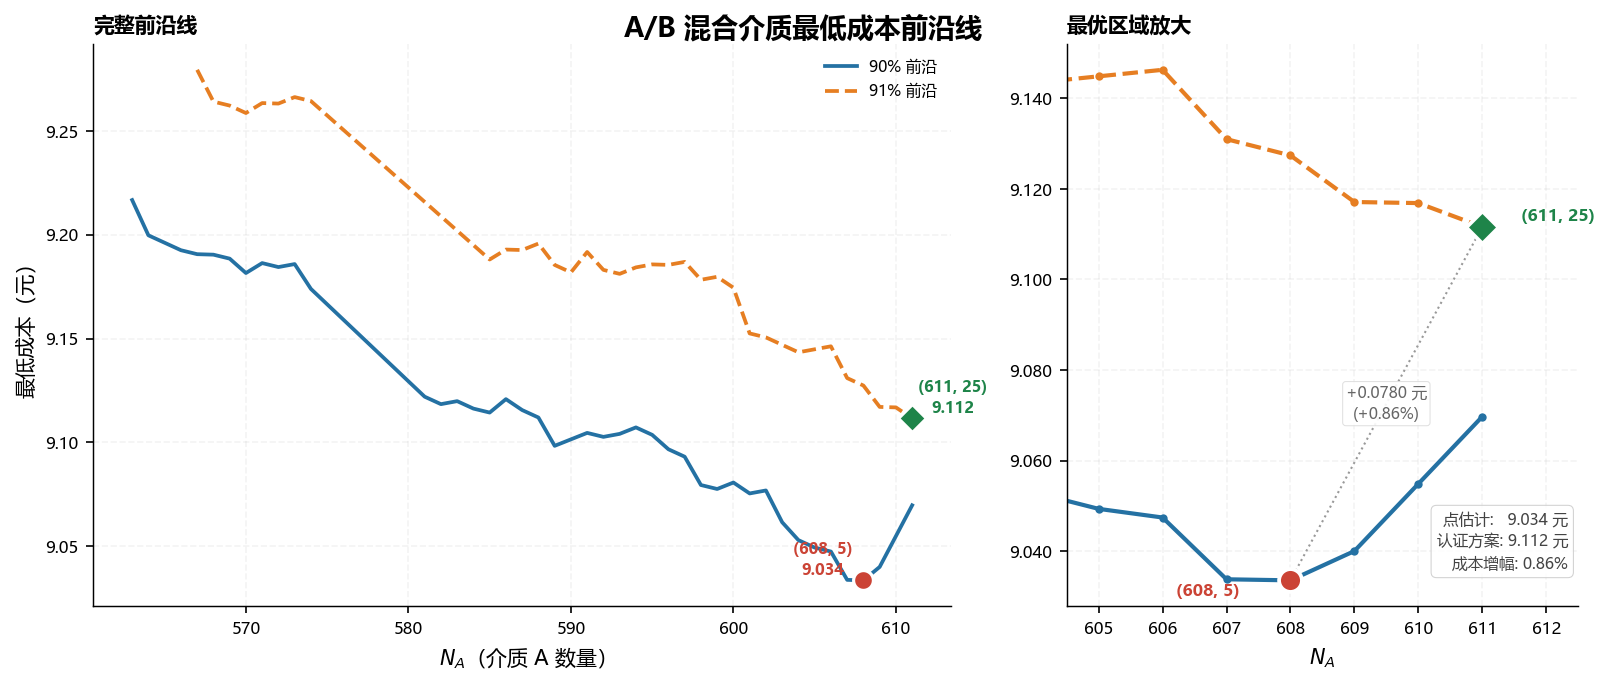

In [46]:
plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.7, "axes.spines.top": False, "axes.spines.right": False,
    "grid.alpha": 0.15, "grid.linestyle": "--",
    "legend.frameon": False,
})

BL   = "#2471a3"   # blue
OR   = "#e67e22"   # orange
RD   = "#cb4335"   # red
GN   = "#1e8449"   # green

plot_90 = frontier_90.sort_values("N_A")
plot_91 = frontier_91.sort_values("N_A")
px, py = int(point_best["N_A"]), float(point_best["成本_元"])
fx, fy = int(frozen_candidate["N_A"]), float(frozen_candidate["成本_元"])

fig = plt.figure(figsize=(11, 4.8))

# ── 左图：完整前沿线 ──
axL = fig.add_axes([0.07, 0.15, 0.52, 0.78])

axL.plot(plot_90["N_A"], plot_90["成本_元"], "-",  color=BL, lw=1.8, label="90% 前沿")
axL.plot(plot_91["N_A"], plot_91["成本_元"], "--", color=OR, lw=1.8, label="91% 前沿")

# 两条前沿最低点的小标记
for frame, c in [(plot_90, BL), (plot_91, OR)]:
    i = frame["成本_元"].idxmin()
    axL.scatter(frame.loc[i,"N_A"], frame.loc[i,"成本_元"],
                color=c, s=30, edgecolors="white", linewidths=0.8, zorder=3)

# 两个关键解
axL.scatter(px, py, color=RD, s=90, zorder=10, edgecolors="white", linewidths=1.5)
axL.scatter(fx, fy, color=GN, s=90, zorder=10, edgecolors="white", linewidths=1.5, marker="D")

axL.text(px - 2.5, py + 0.0008, f"({px}, 5)\n{py:.3f}",
         fontsize=7.5, color=RD, fontweight="bold", ha="center", va="bottom",
         linespacing=1.3)
axL.text(fx + 2.5, fy + 0.0008, f"({fx}, 25)\n{fy:.3f}",
         fontsize=7.5, color=GN, fontweight="bold", ha="center", va="bottom",
         linespacing=1.3)

axL.legend(loc="upper right", fontsize=7.5)
axL.set_xlabel("$N_A$（介质 A 数量）")
axL.set_ylabel("最低成本（元）")
axL.set_title("完整前沿线", fontweight="bold", loc="left", fontsize=10)
axL.grid(True, alpha=0.15, ls="--")

# ── 右图：局部放大 ──
axR = fig.add_axes([0.66, 0.15, 0.31, 0.78])

for frame, ls, c in [(plot_90, "-", BL), (plot_91, "--", OR)]:
    mask = (frame["N_A"] >= px - 4) & (frame["N_A"] <= fx + 2)
    axR.plot(frame["N_A"][mask], frame["成本_元"][mask],
             ls, color=c, lw=2.0, marker="o", ms=4, markeredgewidth=0)

# 灰色虚线连接两点
axR.plot([px, fx], [py, fy], ":", color="#999", lw=1.0, zorder=0)

# 两个关键解
axR.scatter(px, py, color=RD, s=120, zorder=10, edgecolors="white", linewidths=1.8)
axR.scatter(fx, fy, color=GN, s=120, zorder=10, edgecolors="white", linewidths=1.8, marker="D")

# 紧贴标注
axR.text(px - 0.8, py - 0.0005, f"({px}, 5)",  fontsize=8, color=RD, fontweight="bold", ha="right", va="top")
axR.text(fx + 0.6, fy + 0.0004, f"({fx}, 25)", fontsize=8, color=GN, fontweight="bold", ha="left",  va="bottom")

# 成本差
gap = fy - py
axR.annotate(f"+{gap:.4f} 元\n(+{100*gap/py:.2f}%)",
             xy=((px+fx)/2, (py+fy)/2),
             fontsize=7.5, color="#666", ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                       edgecolor="#ddd", alpha=0.9, linewidth=0.5),
             linespacing=1.3)

# 90% 参考线
n90 = int(point_best["N_A"])  # actually we should use Q3 N90, but px=608 is close enough
# Show conduction rate at the optimal point
axR.text(0.98, 0.06, f"点估计:   {py:.3f} 元\n认证方案: {fy:.3f} 元\n成本增幅: {100*gap/py:.2f}%",
         transform=axR.transAxes, fontsize=7.5, color="#444",
         ha="right", va="bottom", linespacing=1.4,
         bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                   edgecolor="#ccc", alpha=0.9, linewidth=0.5))

axR.set_title("最优区域放大", fontweight="bold", loc="left", fontsize=10)
axR.set_xlabel("$N_A$")
axR.set_xlim(px - 3.5, fx + 1.5)
axR.grid(True, alpha=0.15, ls="--")
axR.tick_params(labelsize=8)
axR.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3f}"))

# ── 总标题 ──
fig.suptitle("A/B 混合介质最低成本前沿线", fontweight="bold", fontsize=13, y=0.97)

plt.show()